# 02 · Demand Forecasting
Weekly item demand for the top-15 categories plus the total. Models: naive, seasonal naive, 4-week moving average, damped ETS, ARIMA(1,1,1), a global LightGBM on lag/rolling/calendar features, and an ensemble. Evaluation: 3-fold expanding-window backtest, 8-week horizon.

In [1]:
import sys; sys.path.insert(0, '../src')
import pandas as pd
pd.set_option('display.width', 140)
import matplotlib.pyplot as plt
P = '../data/processed/'

In [2]:
panel = pd.read_parquet(P + 'demand_weekly.parquet')
panel.pivot(index='week', columns='series', values='y').tail()

series,__total__,auto,baby,bed_bath_table,computers_accessories,cool_stuff,electronics,furniture_decor,garden_tools,health_beauty,housewares,perfumery,sports_leisure,telephony,toys,watches_gifts
week,,,,,,,,,,,,,,,,
2018-07-16,1843.0,93.0,48.0,182.0,103.0,27.0,44.0,116.0,40.0,215.0,129.0,51.0,104.0,61.0,42.0,143.0
2018-07-23,1861.0,97.0,65.0,150.0,113.0,26.0,36.0,130.0,58.0,167.0,165.0,61.0,130.0,61.0,40.0,113.0
2018-07-30,2255.0,99.0,90.0,197.0,147.0,40.0,38.0,146.0,32.0,237.0,194.0,70.0,146.0,98.0,42.0,157.0
2018-08-06,2211.0,135.0,61.0,193.0,128.0,39.0,51.0,143.0,52.0,253.0,171.0,55.0,126.0,105.0,52.0,121.0
2018-08-13,2032.0,103.0,48.0,211.0,123.0,29.0,27.0,124.0,41.0,235.0,192.0,51.0,149.0,62.0,45.0,112.0


## Overall leaderboard (lower WAPE is better)

In [3]:
pd.read_parquet(P + 'forecast_leaderboard.parquet').round(3)

,model,mae,rmse,wape,smape,bias
0,arima_111,37.800,91.087,0.192,0.247,0.028
1,ensemble,38.760,90.951,0.197,0.249,0.023
2,moving_avg_4,39.199,94.317,0.200,0.256,0.005
3,lightgbm,39.245,89.125,0.200,0.266,-0.008
4,ets_damped,44.181,102.656,0.225,0.266,0.051
5,naive,44.229,102.782,0.225,0.264,0.066
6,seasonal_naive,106.633,256.734,0.543,0.740,-0.523


## Best model per series

In [4]:
lb = pd.read_parquet(P + 'forecast_leaderboard_by_series.parquet')
lb.sort_values('wape').drop_duplicates('series').round(3)

,series,model,mae,rmse,wape,smape,bias
0,__total__,lightgbm,238.901,318.613,0.135,0.141,0.010
21,bed_bath_table,moving_avg_4,23.792,31.517,0.140,0.147,0.021
98,toys,ensemble,7.492,9.610,0.165,0.175,0.019
14,baby,moving_avg_4,10.438,13.718,0.196,0.199,-0.034
63,health_beauty,moving_avg_4,35.250,42.520,0.197,0.201,-0.043
84,sports_leisure,arima_111,24.976,33.085,0.202,0.217,0.079
42,electronics,lightgbm,9.510,11.918,0.205,0.214,0.063
7,auto,naive,16.750,21.631,0.212,0.220,-0.068
91,telephony,ensemble,14.037,18.847,0.226,0.234,0.003
105,watches_gifts,arima_111,26.770,37.452,0.227,0.220,-0.047


## Error by horizon step

In [5]:
from ecom.forecasting.evaluate import leaderboard
bt = pd.read_parquet(P + 'forecast_backtest.parquet')
leaderboard(bt, ['h', 'model']).pivot(index='h', columns='model', values='wape').round(3)

model,arima_111,ensemble,ets_damped,lightgbm,moving_avg_4,naive,seasonal_naive
h,,,,,,,
1,0.110,0.117,0.126,0.122,0.110,0.117,0.594
2,0.193,0.195,0.218,0.193,0.179,0.212,0.561
3,0.209,0.210,0.232,0.242,0.194,0.234,0.497
4,0.277,0.268,0.308,0.243,0.287,0.326,0.475
5,0.239,0.237,0.278,0.210,0.252,0.285,0.492
6,0.206,0.219,0.248,0.211,0.222,0.251,0.577
7,0.170,0.183,0.210,0.206,0.194,0.203,0.579
8,0.157,0.168,0.199,0.183,0.180,0.199,0.544


## LightGBM feature importance (gain)

In [6]:
pd.read_parquet(P + 'forecast_feature_importance.parquet').head(10)

,feature,gain
0,lag_1,10745.581014
1,roll_mean_4,3976.725947
2,roll_mean_8,1140.737773
3,lag_2,901.144204
4,weekofyear,353.515421
5,lag_4,299.587077
6,lag_12,213.566302
7,series_code,187.784266
8,lag_8,182.220232
9,black_friday,141.026191


## Total demand: history and 8-week forecast (best model, 80% interval)

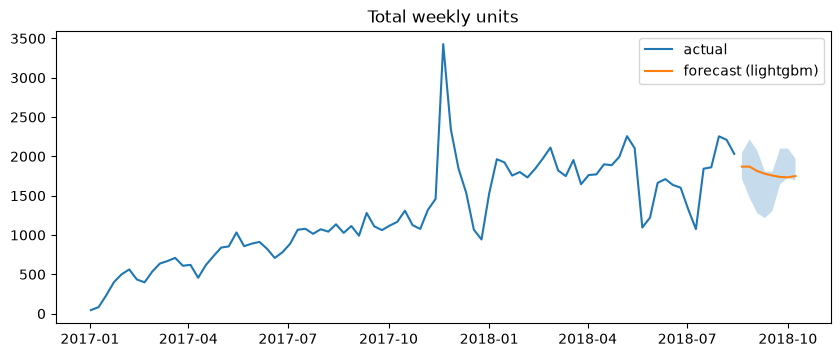

In [7]:
fc = pd.read_parquet(P + 'forecast.parquet')
s = '__total__'
h = panel[panel.series == s]; f = fc[(fc.series == s) & fc.is_best]
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(h.week, h.y, label='actual')
ax.plot(f.week, f.yhat, label=f'forecast ({f.model.iloc[0]})')
ax.fill_between(f.week, f.lower, f.upper, alpha=.25)
ax.legend(); ax.set_title('Total weekly units')
fig.savefig('../reports/figures/06_total_forecast.png', bbox_inches='tight')